In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [14]:
monthly = pd.read_csv("/Users/sahejvasandi/Downloads/monthly_usage.csv")
feature = pd.read_csv("/Users/sahejvasandi/Downloads/feature_frequency.csv")
traffic = pd.read_csv("/Users/sahejvasandi/Downloads/traffic_summary.csv")
geo = pd.read_csv("/Users/sahejvasandi/Downloads/geography_summary.csv")

In [15]:
monthly.head()
feature.head()
traffic.head()
geo.head()

,c_country,events,users
0,US,5132708,94343
1,SG,273257,27646
2,HK,185376,3534
3,DE,176484,6317
4,GB,140493,7953


In [16]:
print("MONTHLY:", monthly.columns)
print("FEATURE:", feature.columns)
print("TRAFFIC:", traffic.columns)
print("GEO:", geo.columns)

MONTHLY: Index(['event_month', 'interface_guess', 'event_count', 'unique_users'], dtype='str')
FEATURE: Index(['interface_guess', 'feature_proxy', 'event_count', 'unique_users'], dtype='str')
TRAFFIC: Index(['traffic_type', 'events', 'users'], dtype='str')
GEO: Index(['c_country', 'events', 'users'], dtype='str')


/var/folders/c7/vwbtyv4d4y5grvht5bfx81d80000gn/T/ipykernel_78119/2873207675.py:28: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis='x', nbins=8)


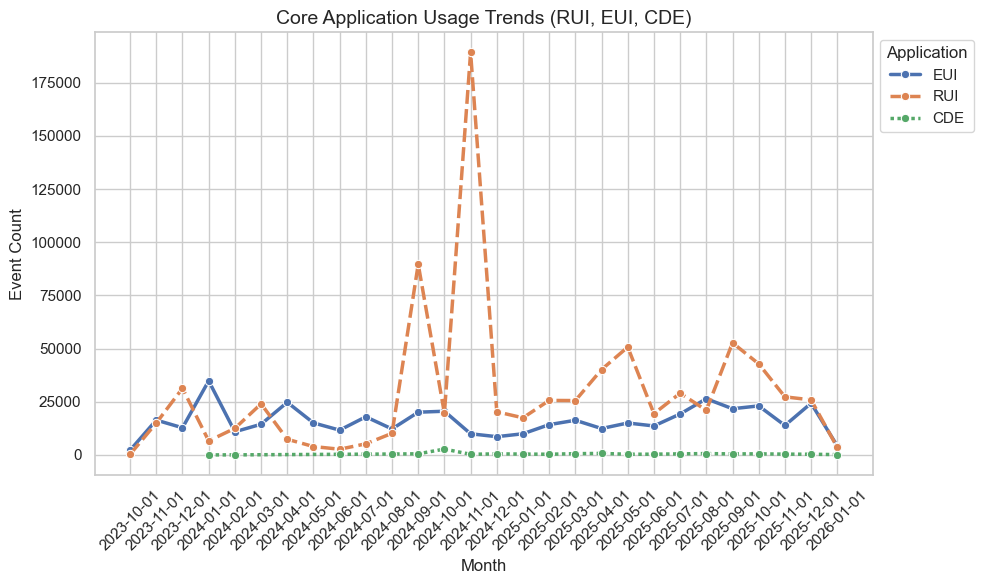

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Remove "OTHER"
filtered = monthly[monthly['interface_guess'] != 'OTHER']

# Plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=filtered,
    x='event_month',
    y='event_count',
    hue='interface_guess',
    marker='o',
    linewidth=2.5,
    style='interface_guess'
)

# Formatting
plt.xticks(rotation=45)
plt.locator_params(axis='x', nbins=8)

plt.title("Core Application Usage Trends (RUI, EUI, CDE)")
plt.xlabel("Month")
plt.ylabel("Event Count")
plt.legend(title="Application", loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

Insight:
RUI consistently drives the highest engagement, with noticeable spikes indicating heavy usage periods. 
EUI shows steady and stable usage, while CDE remains significantly underutilized, suggesting that advanced analytical features may lack visibility or ease of use.

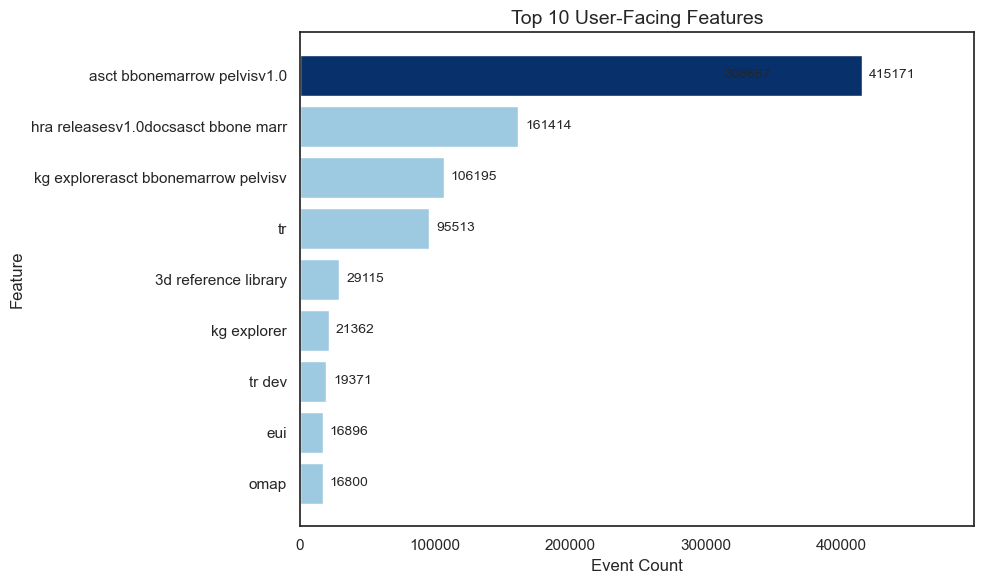

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

plt.rcParams['figure.figsize'] = (10,6)

# 1. Filter system features
filtered_features = feature[
    ~feature['feature_proxy'].str.contains('api|robots|sparql', case=False, na=False)
].copy()

# 2. Remove duplicates (IMPORTANT FIX)
filtered_features = filtered_features.drop_duplicates(subset=['feature_proxy'])

# 3. Get top 10
top_features = filtered_features.sort_values(by='event_count', ascending=False).head(10)

# 4. Clean names
top_features['feature_clean'] = top_features['feature_proxy'].str.replace('/', '', regex=False)
top_features['feature_clean'] = top_features['feature_clean'].str.replace('-', ' ', regex=False)
top_features['feature_clean'] = top_features['feature_clean'].str[:35]

# 5. Sort for better visual order
top_features = top_features.sort_values(by='event_count', ascending=True)

# 6. Colors
colors = ['#9ecae1'] * len(top_features)
colors[-1] = '#08306b'  # highlight top feature

# 7. Plot
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features['feature_clean'],
    top_features['event_count'],
    color=colors
)

# 8. Add labels properly
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5000,
             bar.get_y() + bar.get_height()/2,
             f"{int(width)}",
             va='center',
             fontsize=10)

# 9. Formatting
plt.title("Top 10 User-Facing Features", fontsize=14)
plt.xlabel("Event Count")
plt.ylabel("Feature")

plt.xlim(0, top_features['event_count'].max() * 1.2)

plt.tight_layout()
plt.show()

Insight:
User interactions are highly concentrated in a small set of core features, particularly related to bone marrow and pelvis exploration. 
This strong skew indicates that while key functionalities are well adopted, many other features remain underutilized, highlighting opportunities to improve feature discoverability and user guidance.

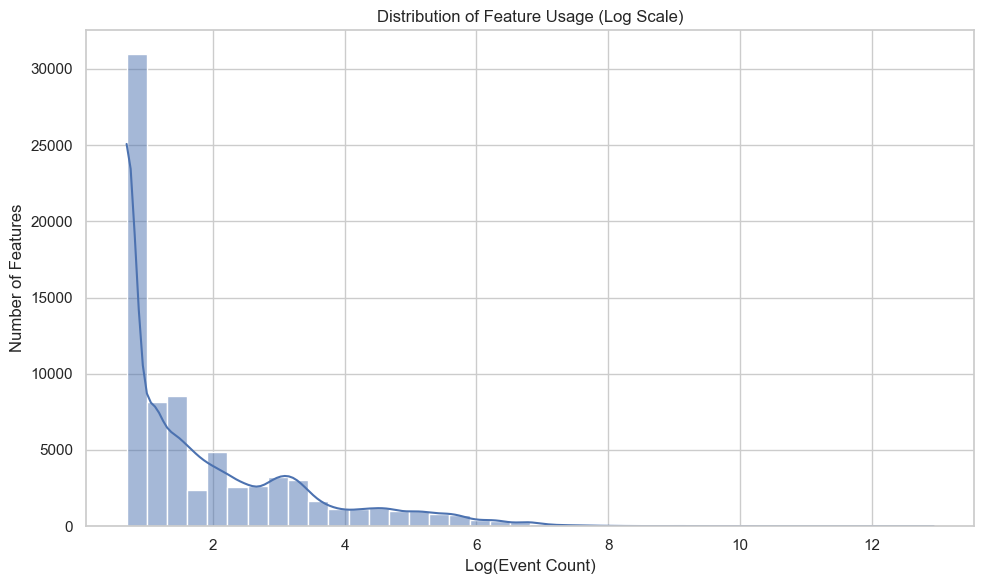

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(filtered_features['event_count']),  # 🔥 log transform
    bins=40,
    kde=True
)

plt.title("Distribution of Feature Usage (Log Scale)")
plt.xlabel("Log(Event Count)")
plt.ylabel("Number of Features")

plt.tight_layout()
plt.show()

Insight:
After applying a log transformation, the distribution clearly reveals a long-tail pattern where a small number of features receive very high usage while the majority have low engagement. This highlights a significant imbalance in feature adoption.

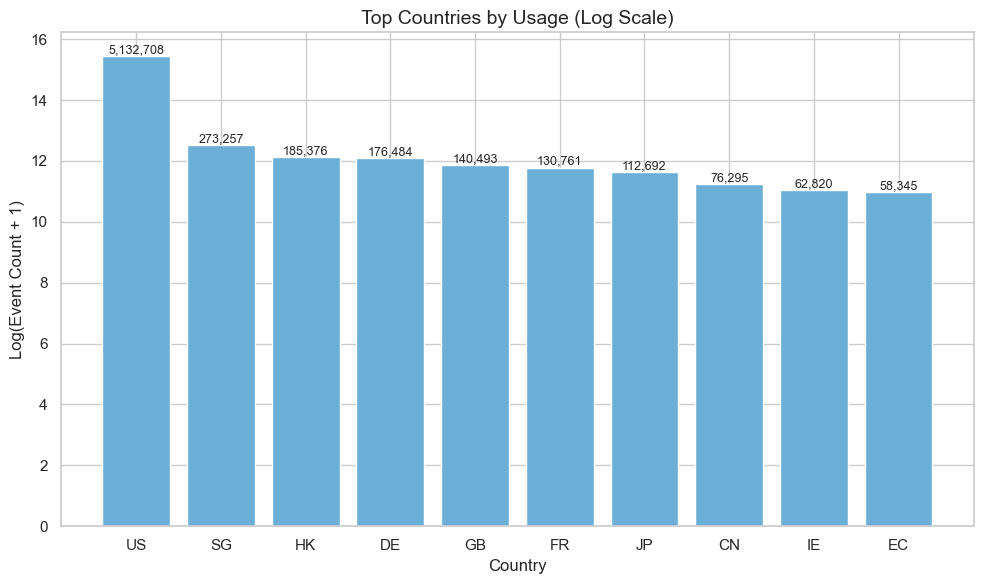

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

# Create log column
geo['log_events'] = np.log1p(geo['events'])

# Sort
top_geo = geo.sort_values(by='events', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))

bars = plt.bar(
    top_geo['c_country'],
    top_geo['log_events'],
    color='#6baed6'
)

# Add labels (actual values, not log)
for i, bar in enumerate(bars):
    actual_value = top_geo['events'].iloc[i]
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{actual_value:,}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Top Countries by Usage (Log Scale)", fontsize=14)
plt.xlabel("Country")
plt.ylabel("Log(Event Count + 1)")

plt.tight_layout()
plt.show()

Insight:
The US dominates platform usage by a significant margin, but after applying a log scale, we observe meaningful engagement across multiple countries such as Singapore, Hong Kong, and Germany. This indicates global adoption, though heavily concentrated in the US.

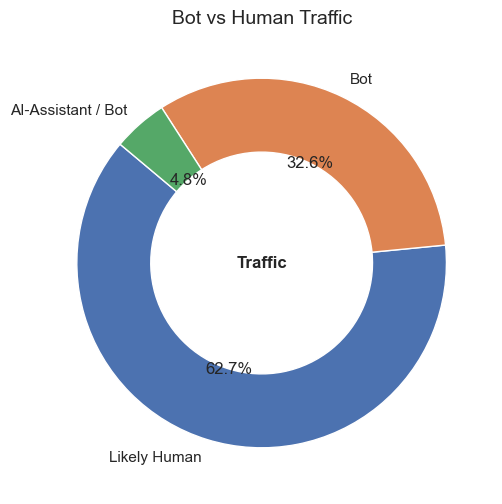

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

colors = ['#4C72B0', '#DD8452', '#55A868']

wedges, texts, autotexts = plt.pie(
    traffic['events'],
    labels=traffic['traffic_type'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4)  # 🔥 donut effect
)

plt.title("Bot vs Human Traffic", fontsize=14)
plt.text(0, 0, "Traffic", ha='center', va='center', fontsize=12, weight='bold')

plt.show()

Insight:
A significant portion of traffic (~37%) originates from bots and AI assistants, which can distort user behavior analysis. This highlights the importance of filtering non-human traffic when evaluating actual user engagement and platform usage patterns.

/var/folders/c7/vwbtyv4d4y5grvht5bfx81d80000gn/T/ipykernel_78119/1813659003.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


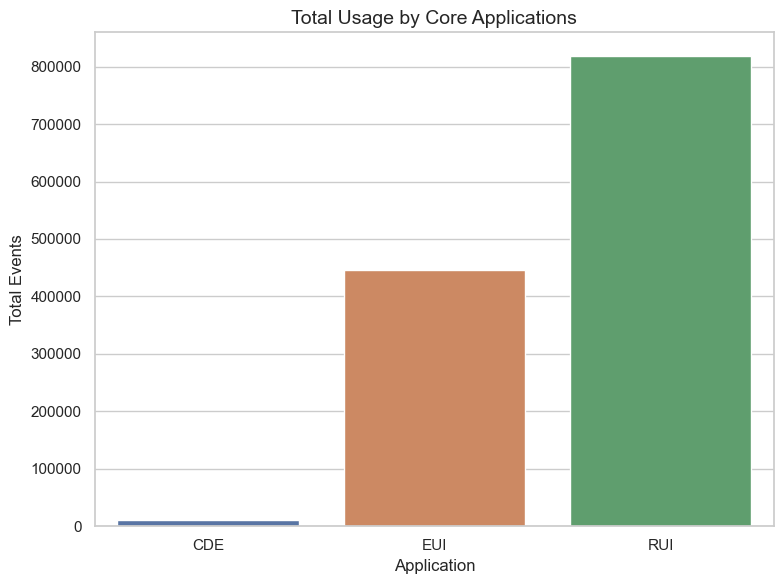

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Filter core apps
core_apps = monthly[monthly['interface_guess'] != 'OTHER']

# Aggregate total usage
total_usage = core_apps.groupby('interface_guess')['event_count'].sum().reset_index()

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=total_usage,
    x='interface_guess',
    y='event_count',
    palette=['#4C72B0', '#DD8452', '#55A868']
)

plt.title("Total Usage by Core Applications", fontsize=14)
plt.xlabel("Application")
plt.ylabel("Total Events")

plt.tight_layout()
plt.show()

Insight:
RUI accounts for the majority of core application usage, followed by EUI, while CDE shows minimal engagement. This reinforces earlier findings that advanced analytical tools are underutilized compared to primary interaction interfaces.